In [1]:
from dataset import *
from rmap import *
import seaborn as sns
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from sklearn.metrics import average_precision_score
from itertools import combinations
from scipy.stats import spearmanr
from sklearn.semi_supervised import LabelPropagation
from copy import deepcopy
import matplotlib.font_manager as fm

## Relation between threshold and remaining edges

In [2]:
# Threshold and the number of pilot BBs that can be selected with our clustering method
suzuki_data = SuzukiDataset(for_conventional_models=False, keepPhBr=False, from_notebook=True)
relation_dict = {
    "Target Core":[],
    "Threshold":[],
    "Portion of retained edges":[],
}
for target_core in [0, 1, 3, 7, 8]:
    rmap = ReactivityMap(
        source_core_inds=None, 
        target_core_ind=target_core, 
        test_bb_inds=[], 
        dataset=suzuki_data
    )
    rmap.get_similarity_matrix()
    sim_mat = rmap.similarity_matrix
    print("Target core", target_core+1)
    for threshold in np.arange(0, 1, 0.05):
        adj = rmap._similarity_matrix_to_adjacency_matrix(sim_mat, threshold)
        portion_retained = np.sum(adj > 0) / len(adj.flatten())
        relation_dict["Target Core"].append(target_core+1)
        relation_dict["Threshold"].append(threshold)
        relation_dict["Portion of retained edges"].append(portion_retained)
        print("    ", round(threshold, 2), len(rmap.select_first_batch(n_select=12, similarity_threshold=threshold)))
    print()

Target core 1
     0.0 1
     0.05 1
     0.1 1
     0.15 1
     0.2 1
     0.25 1
     0.3 1
     0.35 1
     0.4 1
     0.45 1
     0.5 1
     0.55 1
     0.6 2
     0.65 2
     0.7 7
     0.75 7
     0.8 12
     0.85 12
     0.9 12
     0.95 12

Target core 2
     0.0 1
     0.05 1
     0.1 1
     0.15 1
     0.2 1
     0.25 1
     0.3 1
     0.35 1
     0.4 1
     0.45 1
     0.5 1
     0.55 1
     0.6 2
     0.65 3
     0.7 5
     0.75 4
     0.8 12
     0.85 12
     0.9 12
     0.95 12

Target core 4
     0.0 1
     0.05 1
     0.1 1
     0.15 1
     0.2 1
     0.25 1
     0.3 1
     0.35 1
     0.4 1
     0.45 1
     0.5 1
     0.55 1
     0.6 3
     0.65 7
     0.7 6
     0.75 6
     0.8 12
     0.85 12
     0.9 12
     0.95 12

Target core 8
     0.0 1
     0.05 1
     0.1 1
     0.15 1
     0.2 1
     0.25 1
     0.3 1
     0.35 1
     0.4 1
     0.45 1
     0.5 1
     0.55 1
     0.6 2
     0.65 4
     0.7 4
     0.75 4
     0.8 12
     0.85 12
     0.9 12
     0.95 12

Targ

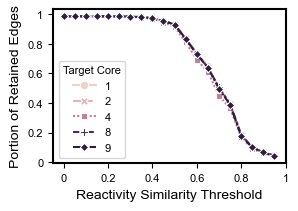

In [3]:
# Relationship between remaining edges and the similarity threshold
fig, ax = plt.subplots(figsize=(3,2))
sns.lineplot(data=pd.DataFrame(relation_dict), x="Threshold", y="Portion of retained edges", hue="Target Core", style="Target Core", markers=True)
ax.set_xlabel("Reactivity Similarity Threshold", fontdict={"size":10, "family":"arial"})
ax.set_ylabel("Portion of Retained Edges", fontdict={"size":10, "family":"arial"})
ax.set_yticks([0, 0.2, 0.4, 0.6, 0.8, 1])
ax.set_xticks([0, 0.2, 0.4, 0.6, 0.8, 1])
ax.set_yticklabels([0, 0.2, 0.4, 0.6, 0.8, 1], fontdict={"size":8, "family":"arial"})
ax.set_xticklabels([0, 0.2, 0.4, 0.6, 0.8, 1], fontdict={"size":8, "family":"arial"})
for axis in ["top", "bottom", "left", "right"]:
    ax.spines[axis].set_linewidth(1.5)
ax.legend(prop=fm.FontProperties(family="Arial", size=8), loc="lower left", title="Target Core", title_fontproperties=fm.FontProperties(family="Arial", size=8))
plt.savefig("../figures/SI/S18A_edges_vs_threshold.svg", dpi=300, bbox_inches="tight", format="svg")

## Relation between predictivity and network form (which is threshold-dependent) and number of pilot BBs

For this experiment, we fix the threshold to a high value (0.82) to ensure 12 pilot BBs can be sampled.
As pilot BBs are selected in an accumulating fashion due to the clustering method's iterative nature, we simply evaluate predictivity on the 57 remaining BBs, excluding the 12 pilot BBs.

In [4]:
# The accumulating fashion of the pilot BB selection can be checked through running this code snippet
suzuki_data = SuzukiDataset(for_conventional_models=False, keepPhBr=False, from_notebook=True)
neighbors_dict = {}
for target_core in [0, 1, 3, 7, 8]:
    rmap = ReactivityMap(source_core_inds=None, target_core_ind=target_core, test_bb_inds=[], dataset=suzuki_data)
    for n_select in [4, 6, 8, 10, 12]:
        selected_bb_inds = rmap.select_first_batch(n_select=n_select)
        print(selected_bb_inds)
    neighbors_dict[target_core] = rmap.neighbors_inds
    print()


[27, 23, 37, 58]
[27, 23, 37, 58, 61, 1]
[27, 23, 37, 58, 61, 1, 62, 25]
[27, 23, 37, 58, 61, 1, 62, 25, 38, 68]
[27, 23, 37, 58, 61, 1, 62, 25, 38, 68, 47, 32]

[53, 2, 65, 58]
[53, 2, 65, 58, 12, 18]
[53, 2, 65, 58, 12, 18, 31, 50]
[53, 2, 65, 58, 12, 18, 31, 50, 61, 10]
[53, 2, 65, 58, 12, 18, 31, 50, 61, 10, 17, 6]

[2, 27, 33, 67]
[2, 27, 33, 67, 62, 25]
[2, 27, 33, 67, 62, 25, 49, 1]
[2, 27, 33, 67, 62, 25, 49, 1, 10, 39]
[2, 27, 33, 67, 62, 25, 49, 1, 10, 39, 55, 19]

[2, 33, 66, 18]
[2, 33, 66, 18, 62, 58]
[2, 33, 66, 18, 62, 58, 31, 10]
[2, 33, 66, 18, 62, 58, 31, 10, 25, 61]
[2, 33, 66, 18, 62, 58, 31, 10, 25, 61, 47, 68]

[2, 52, 67, 12]
[2, 52, 67, 12, 5, 0]
[2, 52, 67, 12, 5, 0, 31, 49]
[2, 52, 67, 12, 5, 0, 31, 49, 10, 14]
[2, 52, 67, 12, 5, 0, 31, 49, 10, 14, 61, 32]



11
15
11
13
11


/var/folders/05/jxqj_ld96mx38n9knzsjp58c0000gn/T/ipykernel_19274/1430464344.py:20: UserWarning: FixedFormatter should only be used together with FixedLocator
  ax.set_xticklabels(np.arange(0, 16, 5), fontdict={"size":8, "family":"arial"})


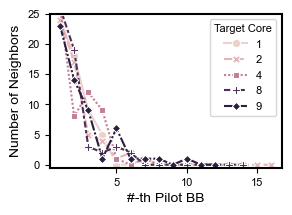

In [ ]:
# Looking at the neighbors of each pilot BBs, selected for all cores
neigh_dict_to_plot = {
    "#-th Pilot BB":[],
    "Target Core":[],
    "Number of Neighbors":[]
}
for i in [0,1,3,7,8]:
    for j, neigh_list in enumerate(neighbors_dict[i]) :
        neigh_dict_to_plot["Target Core"].append(i+1)
        neigh_dict_to_plot["#-th Pilot BB"].append(j+1)
        neigh_dict_to_plot["Number of Neighbors"].append(len(neigh_list))
    print(j)

fig, ax = plt.subplots(figsize=(3,2))
sns.lineplot(neigh_dict_to_plot, x="#-th Pilot BB", y="Number of Neighbors", style="Target Core", hue="Target Core", markers=True)
ax.set_ylim(-0.5, 25)
ax.set_yticks(np.arange(0, 26, 5))
ax.set_ylabel("Number of Neighbors", fontdict={"size":10, "family":"arial"})
ax.set_yticklabels(np.arange(0, 26, 5), fontdict={"size":8, "family":"arial"})
ax.set_xticklabels(np.arange(0, 16, 5), fontdict={"size":8, "family":"arial"})
ax.set_xlabel("#-th Pilot BB", fontdict={"size":10, "family":"arial"})
for axis in ["top", "bottom", "left", "right"]:
    ax.spines[axis].set_linewidth(1.5)
ax.legend(prop=fm.FontProperties(family="Arial", size=8), loc="upper right", title="Target Core", title_fontproperties=fm.FontProperties(family="Arial", size=8))

plt.savefig("../figures/SI/FigureS33_pilotBB_neighbors.svg", dpi=300, bbox_inches="tight", format="svg")

In [57]:
neigh_df = pd.DataFrame(neigh_dict_to_plot)

neigh_df[neigh_df["#-th Pilot BB"] >= 6]

,#-th Pilot BB,Target Core,Number of Neighbors
5,6,1,0
6,7,1,1
7,8,1,0
8,9,1,0
9,10,1,0
10,11,1,0
11,12,1,0
17,6,2,2
18,7,2,0
19,8,2,0


In [49]:
### Looking at performances across all hyperparameters (number of pilot BBs, pilot BB threshold, LP threshold)

def _check_num_components_and_adjust(adj, print_info=None):
    """ Checking the number of connected components of a network constructed by the given adjacency matrix.
    Then treat the adjacency matrix by selected method as specified through the lp_epsilon parser argument.

    Parameters
    ----------
    adj : np.ndarray of shape (n_BBs, n_BBs)
        Adjacency matrix to construct the network.
        
    Returns
    ------- 
    """
    G = nx.from_numpy_array(adj)
    n_comp = nx.number_connected_components(G)
    if (print_info is not None) and n_comp > 1:
        print("Number of Connected Components", n_comp, print_info)
    if n_comp > 1 :
        adj += 0.001  # To prevent division error
    return adj

suzuki_data = SuzukiDataset(for_conventional_models=False, keepPhBr=False, from_notebook=True)
THRESHOLDS = [0.7, 0.75, 0.8, 0.82, 0.85]
LP_THRESHOLDS = [0.6, 0.7, 0.8, 0.82, 0.85]
NUM_PILOTS = [4, 6, 8, 10, 12]
from itertools import product
score_dict = {}
for target_core in [0, 1, 3, 7, 8]:
    rmap2 = ReactivityMap(source_core_inds=None, target_core_ind=target_core, test_bb_inds=[], dataset=suzuki_data)
    binarized_target = deepcopy(rmap2.target_reactivity_array)
    binarized_target[binarized_target <= 1] = 0
    binarized_target[binarized_target == 2] = 1
    score_dict.update({target_core:{}})
    for n_pilot in NUM_PILOTS:
        scores = np.zeros((5, 5)) # row: pilot threhsold, column: lp_threshold
        for pilot_threshold, lp_threshold in product(THRESHOLDS, LP_THRESHOLDS):
            pilot_ind = THRESHOLDS.index(pilot_threshold)
            lp_ind = LP_THRESHOLDS.index(lp_threshold)

            rmap = ReactivityMap(source_core_inds=None, target_core_ind=target_core, test_bb_inds=[], dataset=suzuki_data)
            _ = rmap.get_similarity_matrix()
            rmap_selected_inds = rmap.select_first_batch(n_select=n_pilot, similarity_threshold=pilot_threshold)
            remaining_bb_inds = [bb_ind for bb_ind in range(len(rmap.train_bb_inds)) if bb_ind not in rmap_selected_inds]
            if len(rmap_selected_inds) >= n_pilot :
                adj = rmap._similarity_matrix_to_adjacency_matrix(
                    rmap.similarity_matrix, lp_threshold
                )
                adj = _check_num_components_and_adjust(adj)
                def _kernel(X, y):
                    return adj
                X_ohe = np.identity(len(rmap.train_bb_inds))
                y = -1 * np.ones(len(rmap.train_bb_inds))
                y[rmap_selected_inds] = rmap.target_reactivity_array[
                    rmap_selected_inds
                ]
                y[y==1] = 0
                y[y==2] = 1
                lp = LabelPropagation(kernel=_kernel, n_jobs=-1)
                lp.fit(X_ohe, y)
                lp_pred_proba = lp.predict_proba(X_ohe)[:, -1]
                score = average_precision_score(
                    binarized_target[remaining_bb_inds], lp_pred_proba[remaining_bb_inds]
                )
            else :
                score = 0
            scores[pilot_ind, lp_ind] = score
        score_dict[target_core].update({n_pilot:scores})

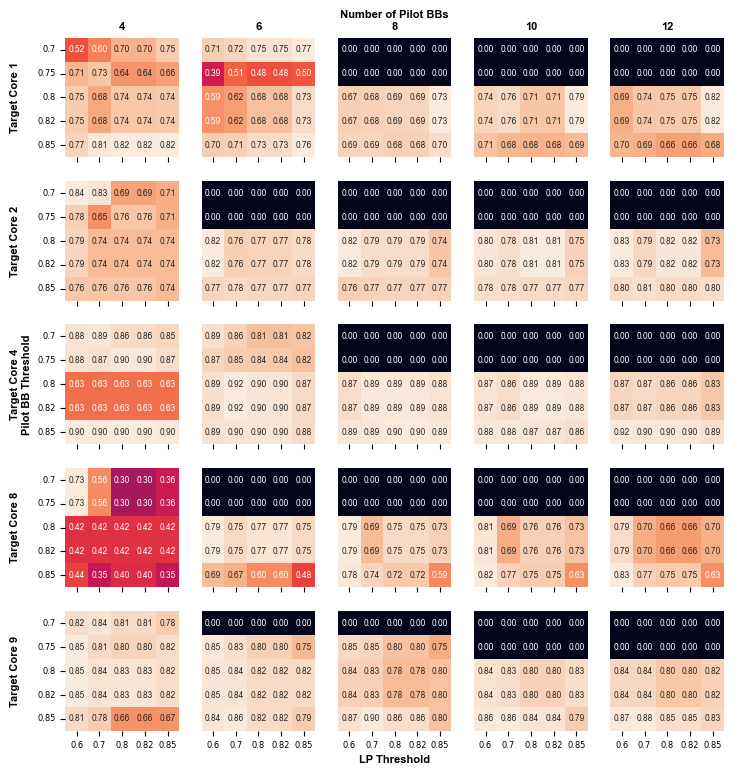

In [59]:
fig, ax = plt.subplots(figsize=(8.5, 9), ncols=5, nrows=5)

for j, target_core in enumerate([0,1,3,7,8]):
    for i, n_pilot in enumerate(NUM_PILOTS):
        if j == 4 :
            xticklabels=LP_THRESHOLDS
        else :
            xticklabels=[""]*5
        if i == 0 :
            yticklabels=THRESHOLDS
        else :
            yticklabels=[""]*5
        sns.heatmap(score_dict[target_core][n_pilot], ax=ax[j,i],
                    xticklabels=xticklabels,
                    yticklabels=yticklabels if i ==0 else False, 
                    cbar=False, annot=True, fmt=".2f", vmin=0,
                    annot_kws={"fontsize": 6, "fontfamily": "arial"},)
        ax[j, i].set_xticklabels(ax[j, i].get_xticklabels(), rotation=0, fontsize=6)
        if j == 0:
            if i == 2 :
                ax[j, i].set_title(f"Number of Pilot BBs\n{NUM_PILOTS[i]}", fontdict={"size":8, "family":"arial", "weight":"bold"})
            else:
                ax[j, i].set_title(f"{NUM_PILOTS[i]}", fontdict={"size":8, "family":"arial", "weight":"bold"})
        if j == 4 and i == 2:
            ax[j, i].set_xlabel("LP Threshold", fontdict={"size":8, "family":"arial", "weight":"bold"})
        if i == 0 :
            ax[j, i].set_yticklabels(THRESHOLDS, rotation=0, fontsize=6)
            if j ==2 :
                ax[j, i].set_ylabel(f"Target Core {target_core+1}\nPilot BB Threshold", fontdict={"size":8, "family":"arial", "weight":"bold"})
            else :
                ax[j, i].set_ylabel(f"Target Core {target_core+1}\n", fontdict={"size":8, "family":"arial", "weight":"bold"})

plt.savefig("../figures/SI/FigureS33_all_hyperparam_combinations.svg", dpi=300, bbox_inches="tight", format="svg")